In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [8]:
df = pd.read_csv("train.csv")
df

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,11284,11285,18,Female,1.04,4.86,6.58,2.73,0.35,1.57,10,462,63,2,62.40,1,80,80.24,35.63
15996,11964,11965,29,Male,4.85,8.61,4.66,5.79,1.98,5.08,9,317,47,3,40.52,10,43,57.97,40.07
15997,5390,5391,25,Other,7.97,8.72,11.30,2.54,3.67,3.57,13,290,105,7,75.09,5,71,40.71,63.14
15998,860,861,21,Female,2.64,8.64,1.47,5.01,5.24,3.18,3,62,116,18,73.99,6,31,76.56,41.62


In [9]:
df.isnull().sum()

id                       0
student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

In [10]:
df.shape

(16000, 19)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     16000 non-null  int64  
 1   student_id             16000 non-null  int64  
 2   age                    16000 non-null  int64  
 3   gender                 16000 non-null  str    
 4   study_hours_per_day    16000 non-null  float64
 5   sleep_hours            16000 non-null  float64
 6   phone_usage_hours      16000 non-null  float64
 7   social_media_hours     16000 non-null  float64
 8   youtube_hours          16000 non-null  float64
 9   gaming_hours           16000 non-null  float64
 10  breaks_per_day         16000 non-null  int64  
 11  coffee_intake_mg       16000 non-null  int64  
 12  exercise_minutes       16000 non-null  int64  
 13  assignments_completed  16000 non-null  int64  
 14  attendance_percentage  16000 non-null  float64
 15  stress_level 

In [14]:
df.describe()

,id,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,10006.506875,10007.506875,23.020937,5.254446,6.515254,6.258693,3.995989,2.985526,2.976373,7.539625,249.035250,59.832125,9.492313,69.894694,5.478813,64.430375,70.377071,50.146637
std,5790.786923,5790.786923,3.753283,2.743874,2.033761,3.305756,2.311722,1.731141,1.733127,4.017236,143.732208,34.676427,5.781352,17.408698,2.867785,20.226804,17.293340,16.095733
min,1.000000,2.000000,17.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,4993.750000,4994.750000,20.000000,2.890000,4.760000,3.390000,2.000000,1.480000,1.477500,4.000000,124.000000,30.000000,4.000000,54.740000,3.000000,47.000000,55.617500,38.657500
50%,10020.500000,10021.500000,23.000000,5.250000,6.520000,6.230000,3.990000,2.970000,2.950000,8.000000,248.000000,60.000000,9.000000,69.865000,5.000000,65.000000,70.545000,50.220000
75%,15029.250000,15030.250000,26.000000,7.632500,8.320000,9.100000,5.970000,4.480000,4.490000,11.000000,372.000000,90.000000,15.000000,85.020000,8.000000,82.000000,85.480000,61.840000
max,19999.000000,20000.000000,29.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [15]:
df.head(5)

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [16]:
df['gender'] = df['gender'].map({"Other": 0, "Female": 1, "Male": 2})

In [17]:
df.head(5)

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,0,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,1,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,2,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,1,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,2,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [19]:
df.describe()

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,10006.506875,10007.506875,23.020937,1.443188,5.254446,6.515254,6.258693,3.995989,2.985526,2.976373,7.539625,249.035250,59.832125,9.492313,69.894694,5.478813,64.430375,70.377071,50.146637
std,5790.786923,5790.786923,3.753283,0.568698,2.743874,2.033761,3.305756,2.311722,1.731141,1.733127,4.017236,143.732208,34.676427,5.781352,17.408698,2.867785,20.226804,17.293340,16.095733
min,1.000000,2.000000,17.000000,0.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,4993.750000,4994.750000,20.000000,1.000000,2.890000,4.760000,3.390000,2.000000,1.480000,1.477500,4.000000,124.000000,30.000000,4.000000,54.740000,3.000000,47.000000,55.617500,38.657500
50%,10020.500000,10021.500000,23.000000,1.000000,5.250000,6.520000,6.230000,3.990000,2.970000,2.950000,8.000000,248.000000,60.000000,9.000000,69.865000,5.000000,65.000000,70.545000,50.220000
75%,15029.250000,15030.250000,26.000000,2.000000,7.632500,8.320000,9.100000,5.970000,4.480000,4.490000,11.000000,372.000000,90.000000,15.000000,85.020000,8.000000,82.000000,85.480000,61.840000
max,19999.000000,20000.000000,29.000000,2.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


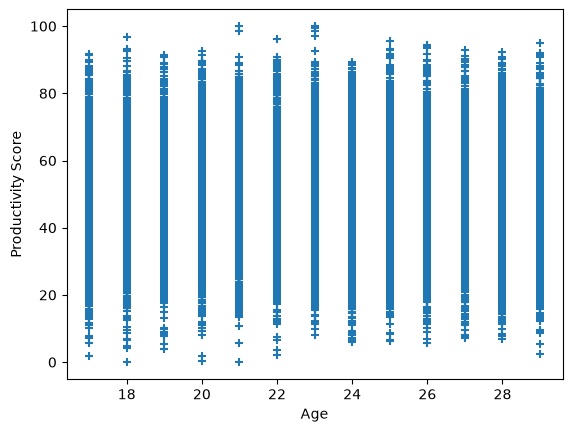

In [22]:
%matplotlib inline
plt.xlabel("Age")
plt.ylabel("Productivity Score")
plt.scatter(df.age, df.productivity_score, marker = "+")

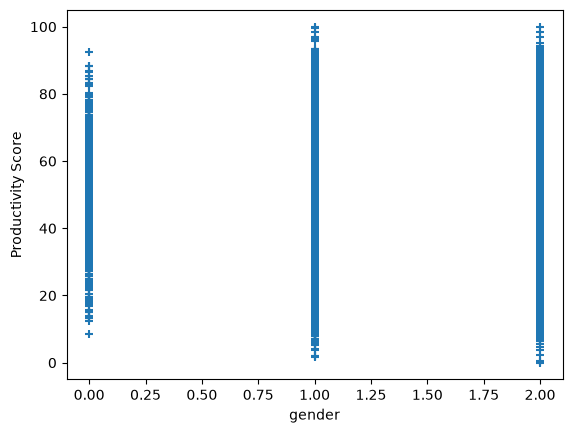

In [24]:
%matplotlib inline
plt.xlabel("gender")
plt.ylabel("Productivity Score")
plt.scatter(df.gender, df.productivity_score, marker = "+")

##Study hours per day (Linear Relationship)
obv : more hours studied a day = higher production score

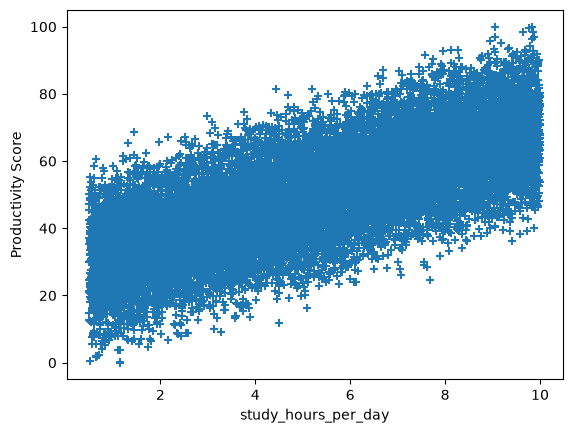

In [26]:
%matplotlib inline
plt.xlabel("study_hours_per_day")
plt.ylabel("Productivity Score")
plt.scatter(df.study_hours_per_day, df.productivity_score, marker = "+")

##Sleep hours (semi linear relationship)
Obv: more sleep = higher productiviy score

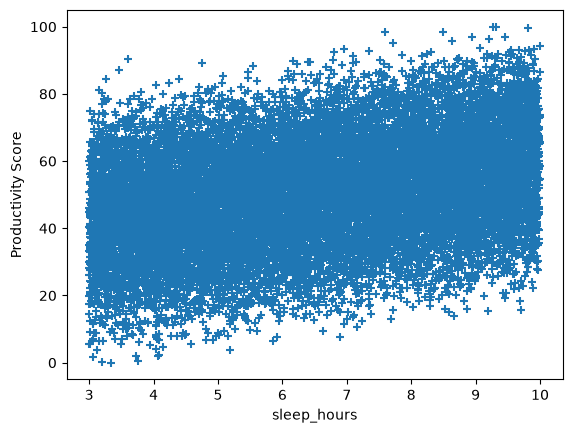

In [27]:
%matplotlib inline
plt.xlabel("sleep_hours")
plt.ylabel("Productivity Score")
plt.scatter(df.sleep_hours, df.productivity_score, marker = "+")

In [ ]:
##Phone usage (linear relationship)
Obv: less amount of house the more production hours

C:\Users\tkiya\anaconda3\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\tkiya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


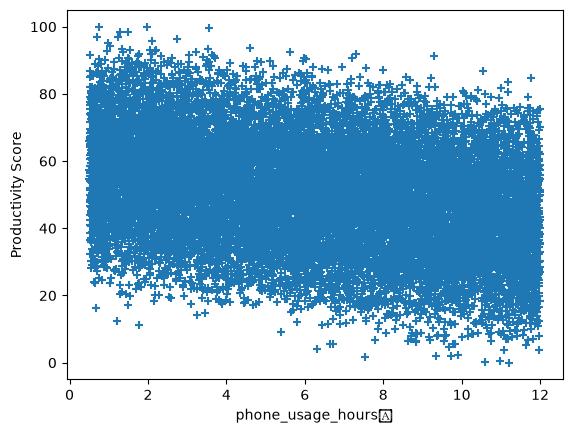

In [28]:
%matplotlib inline
plt.xlabel("phone_usage_hours	")
plt.ylabel("Productivity Score")
plt.scatter(df.phone_usage_hours	, df.productivity_score, marker = "+")

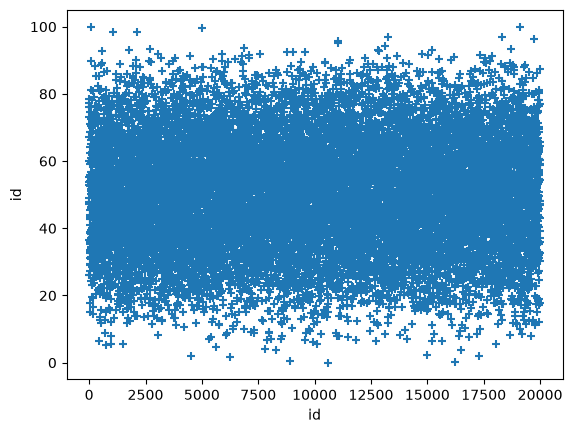

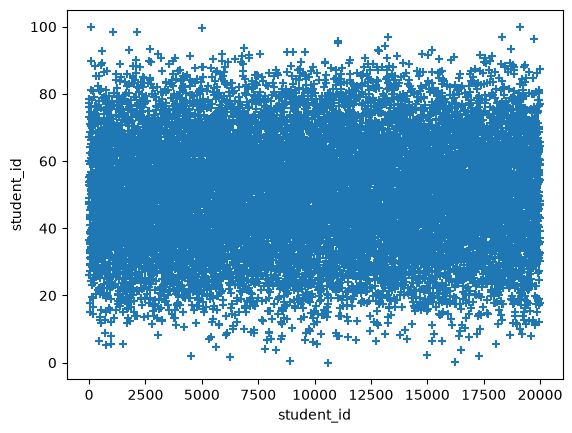

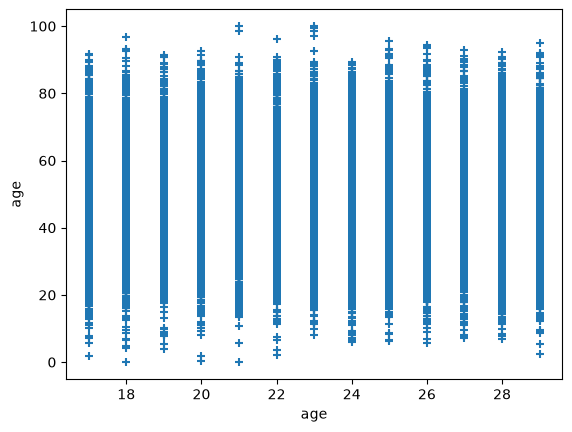

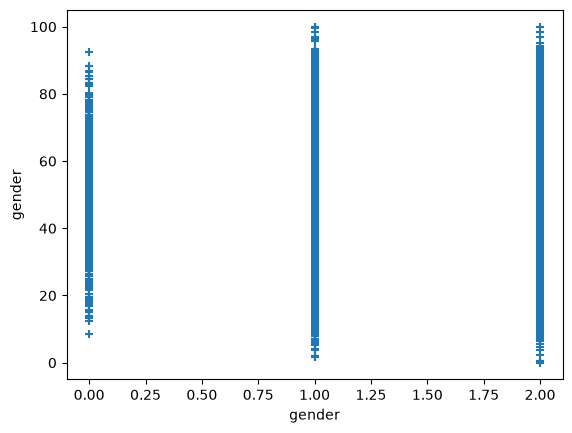

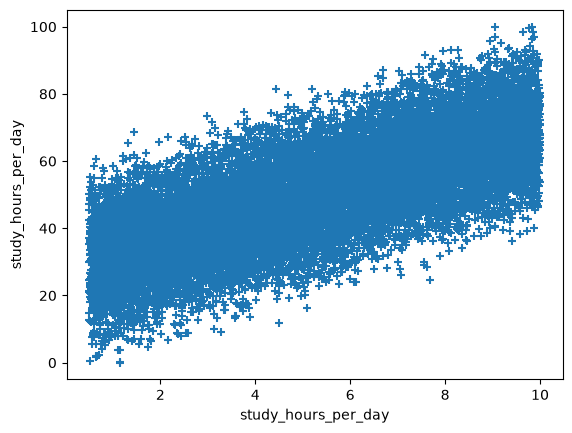

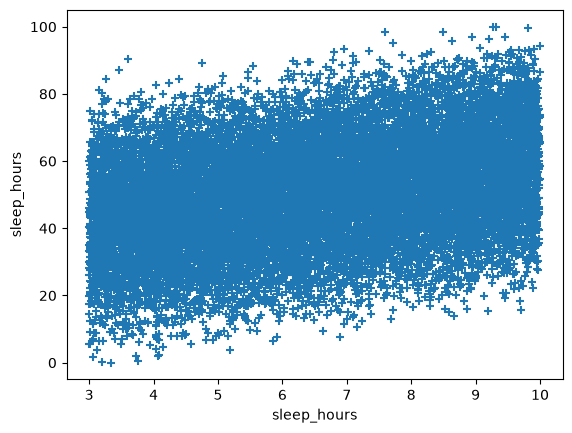

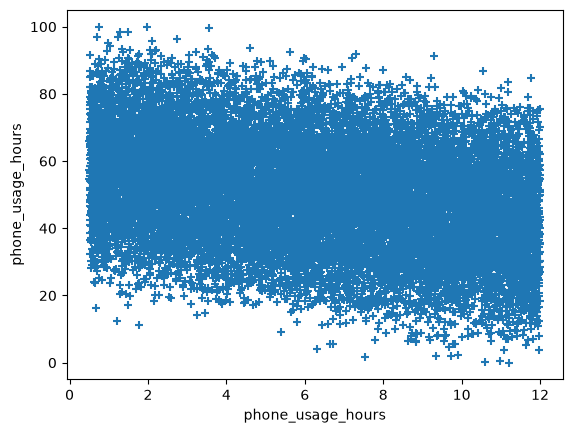

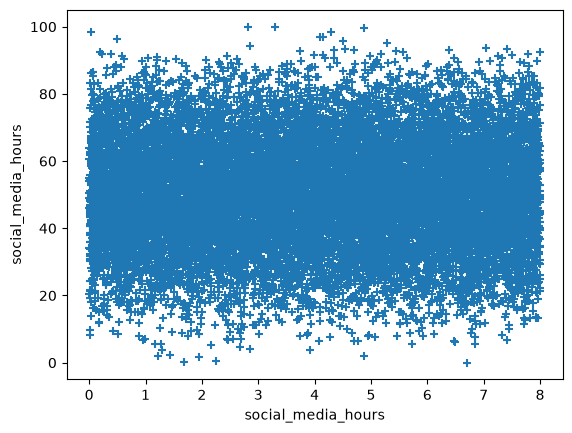

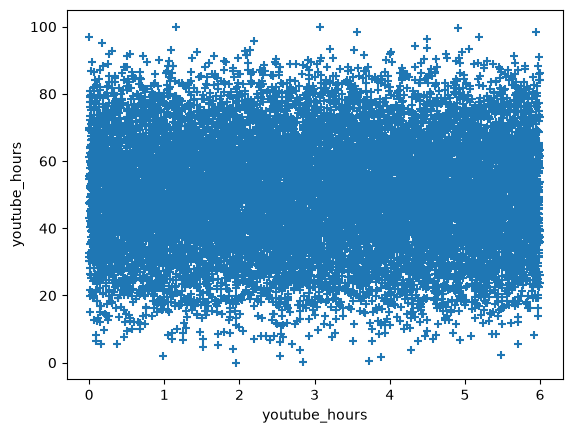

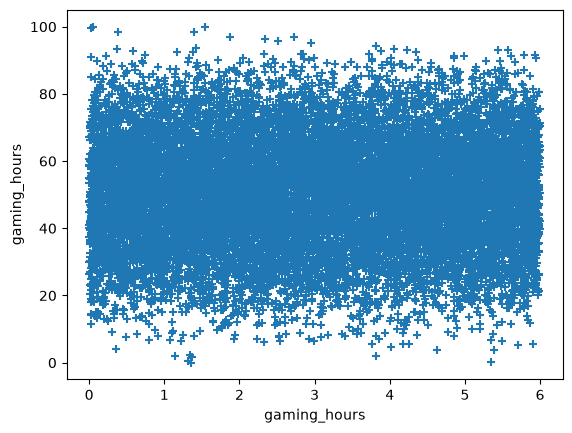

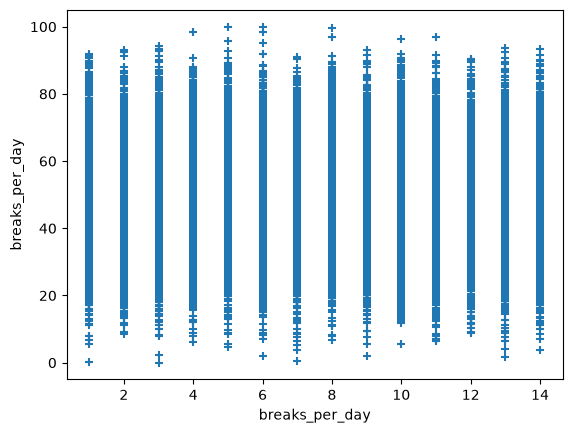

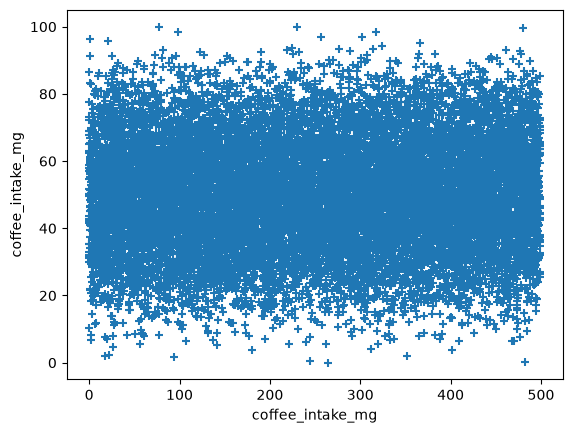

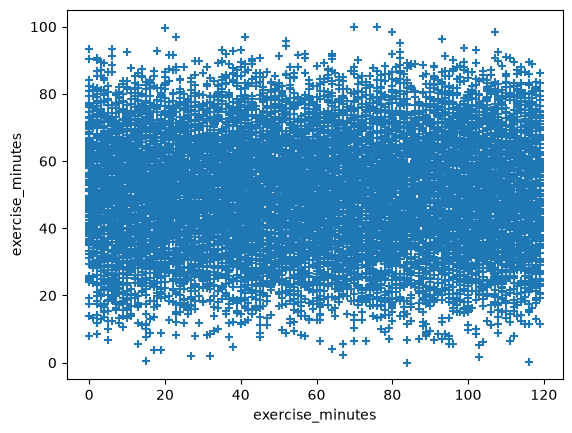

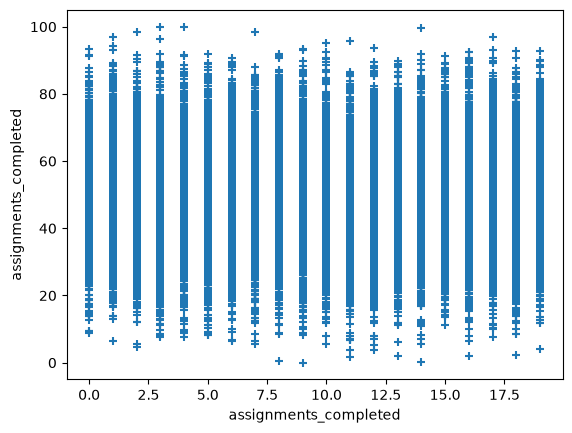

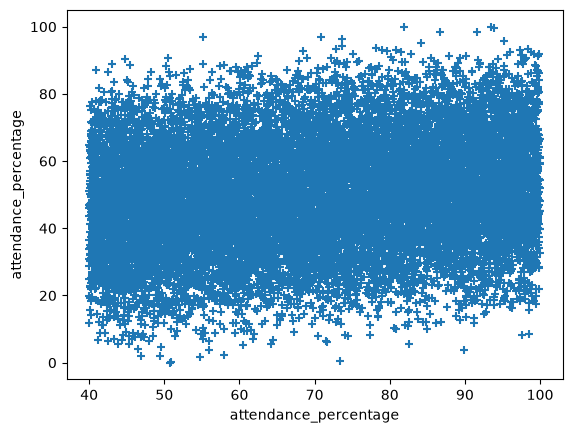

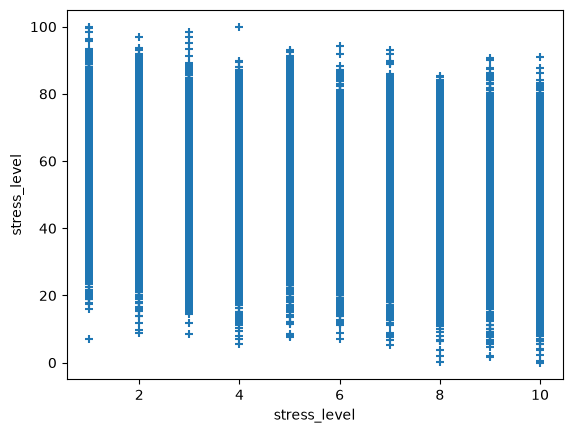

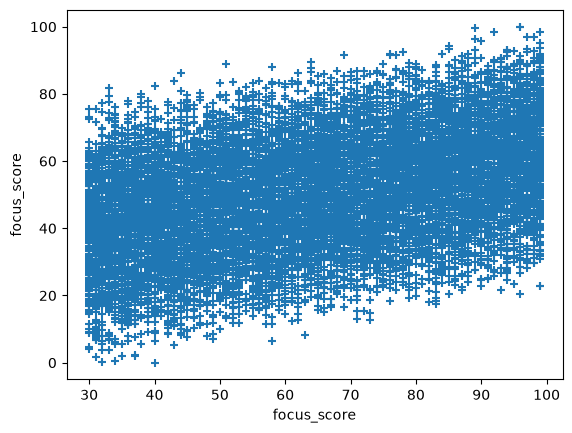

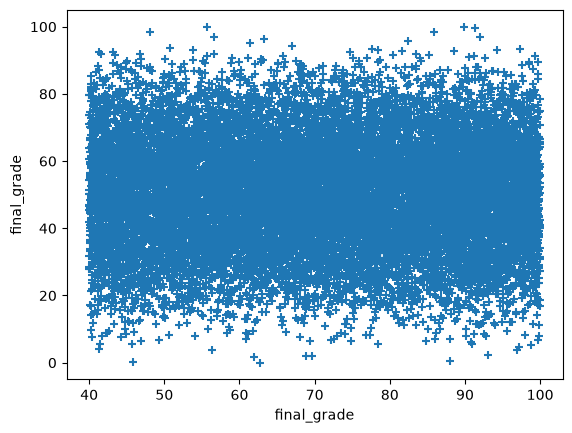

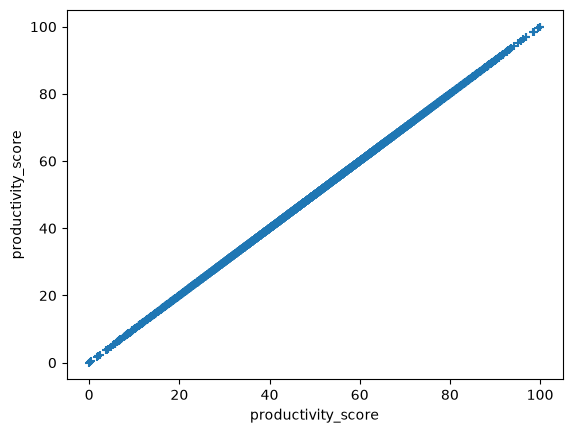

In [29]:
for i in df.columns:
    %matplotlib inline
    plt.xlabel(i)
    plt.ylabel(i)
    plt.scatter(df[i]	, df.productivity_score, marker = "+")
    plt.show()